In [58]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 

sys.path.append(os.path.join(project_root, 'Scripts'))

from model_utils.data import *
from data_utils.visualization import *

from data_utils.colors_config import *
from data_utils.processing import *
from model_utils.preprocessing import *

import umap
#from model_utils.data import *
#from model_utils.trainer import *

In [59]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests


import warnings
warnings.filterwarnings('ignore')

In [60]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
pio.renderers.default = "png"
import pandas as pd
import plotly.express as px

from adjustText import adjust_text

import config
from data_utils import *

In [61]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [62]:
data.shape

(97462, 41)

In [63]:
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code
0,Nathan Redmond,MID,Southampton,1.5,0,0,3,0,0.0,403,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2022-08-06T14:00:00,1,0,0,0,0,1,0,5871.0,0,1.0,4.0,0.0,1,0,0,0,5.5,False,0,2223,1,83283
1,Junior Stanislas,MID,Bournemouth,1.1,0,0,3,0,0.0,58,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2022-08-06T14:00:00,1,0,0,0,0,1,0,9491.0,0,0.0,2.0,0.0,1,0,0,0,5.0,True,0,2223,1,56872
2,Armando Broja,FWD,Chelsea,2.0,0,0,3,0,0.3,150,0.0,0.0,0.0,0.0,0,0,2.5,5.2,2022-08-06T16:30:00,15,0,0,0,0,1,0,124903.0,0,1.0,0.0,19.0,1,0,0,0,5.5,False,0,2223,1,440323
3,Fabian Schär,DEF,Newcastle,2.4,0,3,43,1,14.6,366,0.0,0.0,0.0,0.0,0,1,10.6,66.0,2022-08-06T14:00:00,90,0,0,0,0,1,0,40132.0,0,0.0,2.0,25.0,15,0,0,0,4.5,True,0,2223,1,119471
4,Jonny Evans,DEF,Leicester,1.9,0,0,15,0,1.3,249,0.0,0.0,0.0,0.0,2,0,1.5,14.0,2022-08-07T13:00:00,90,0,0,0,0,1,0,24256.0,0,2.0,2.0,0.0,1,0,0,0,4.5,True,0,2223,1,37642


In [64]:
data.season.unique()

<ArrowStringArray>
['2223', '2324', '2425', '2526']
Length: 4, dtype: str

In [65]:
data.team.unique()

<ArrowStringArray>
[   'Southampton',    'Bournemouth',        'Chelsea',      'Newcastle',
      'Leicester',  'Nott'm Forest', 'Crystal Palace',         'Wolves',
      'Brentford',          'Spurs',       'West Ham',      'Liverpool',
          'Leeds',         'Fulham',       'Brighton',       'Man City',
        'Man Utd',        'Everton',        'Arsenal',    'Aston Villa',
  'Sheffield Utd',        'Burnley',          'Luton',        'Ipswich',
     'Sunderland']
Length: 25, dtype: str

In [66]:
data.shape

(97462, 41)

In [67]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float32)
    df["season"] = df["season"].astype(int)

    return df

In [68]:
data.rename(columns={
    "expected_goals_conceded" : "xg_conceded",
    "expected_goals" : "xg",
    "expected_goal_involvements" : "xg_involvements",
    "team_expected_points" : "team_xp",
    "opp_expected_points" : "opp_xp",
    "expected_assists" : "xa"
}, inplace=True)

In [69]:
def exp_per_90(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.reset_index(drop=True)

    minutes = pd.to_numeric(df['minutes'], errors='coerce').replace(0, np.nan)

    for col in x_cols:
        new_col = f"{col}_per_90"

        num_col = pd.to_numeric(df[col], errors='coerce')

        result = num_col / (minutes / 90.0)

        result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[new_col] = result.astype(float)

    return df

In [70]:
data = numpy_dtypes(data)

data = exp_per_90(data, [c for c in data.columns if "x" in c and c != "ict_index" and c != "xP"])


In [71]:
data.shape

(97462, 45)

In [72]:
data = data.loc[data.position != "AM", :]

In [73]:
data = sort_data(data)
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00,0.0,0.0,0.0,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,2223,32.0,11948.0,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00,0.0,0.0,0.0,0.0,0.0,33.0,0.0,33.0,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,2223,33.0,11948.0,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00,0.0,0.0,0.0,0.0,0.0,34.0,0.0,84.0,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,2223,34.0,11948.0,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00,0.0,0.0,0.0,0.0,0.0,35.0,0.0,111.0,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,2223,35.0,11948.0,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00,0.0,0.0,0.0,0.0,0.0,36.0,0.0,134.0,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,2223,36.0,11948.0,0.0,0.0,0.0,0.0


In [74]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
count,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000,97140.000000,97140.000000,97140.000000,97140.000000,97140.000000,9.714000e+04,9.714000e+04,9.714000e+04,97140.000000,97140.000000,97140.000000,97140.000000,97140.00000,97140.000000,97140.000000,97140.00000,97140.000000
mean,1.105483,0.105147,0.266193,14.614412,0.255497,11.865573,362.497498,0.069786,0.183202,0.114245,1.215297,1.229957,0.112456,4.079854,17.970446,80.489128,0.004499,0.002193,0.001277,0.004952,20.207277,0.229566,190394.875,0.869003,1.369652,1.632602,11.007041,1.129391,1.198842e+03,1.439444e+04,1.319553e+04,4.875769,0.152162,2353.145893,20.207277,293308.46875,0.041317,0.108278,0.06834,0.723386
std,1.921653,0.528265,1.257640,50.460594,1.005937,48.536869,219.919434,0.322145,0.816867,0.574260,4.178362,4.100410,0.599189,14.379964,63.782558,268.809052,0.071531,0.055622,0.035993,0.070194,10.791747,3.041451,625746.250,3.068596,1.209240,1.330649,45.658730,2.326022,7.435866e+04,6.244230e+04,5.589697e+04,1.048721,0.632377,102.582428,10.791747,175051.15625,0.379449,0.650687,0.49023,2.215681
min,-3.000000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,3.600000,0.000000,2223.000000,1.000000,11948.00000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,175.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,1350.000,0.000000,0.000000,1.000000,0.000000,0.000000,-9.130000e+02,1.800000e+01,8.200000e+01,4.300000,0.000000,2223.000000,11.000000,156074.00000,0.000000,0.000000,0.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,352.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000,11166.500,0.000000,1.000000,1.000000,0.000000,0.000000,-5.100000e+01,2.340000e+02,6.200000e+02,4.500000,0.000000,2324.000000,21.000000,223723.00000,0.000000,0.000000,0.00000,0.000000
75%,1.700000,0.000000,0.000000,9.000000,0.000000,2.800000,544.000000,0.010000,0.024792,0.000000,0.770000,1.000000,0.000000,2.400000,10.200000,83.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,80007.000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000e+01,2.991000e+03,5.338250e+03,5.000000,0.000000,2425.000000,30.000000,469142.00000,0.010345,0.036371,0.00000,1.077966
max,24.799999,19.000000,36.000000,845.000000,15.000000,1587.900024,866.000000,9.600000,19.980000,13.750000,69.620003,68.000000,14.000000,320.500000,1095.400024,3060.000000,2.000000,2.000000,2.000000,1.000000,38.000000,122.000000,9582624.000,34.000000,8.000000,9.000000,941.000000,26.000000,1.674116e+06,1.689375e+06,2.766073e+06,15.400000,10.000000,2526.000000,38.000000,704232.00000,50.399998,62.999996,54.00000,128.699997


In [75]:
data.shape

(97140, 45)

Text(0, 0.5, 'Liczba graczy')

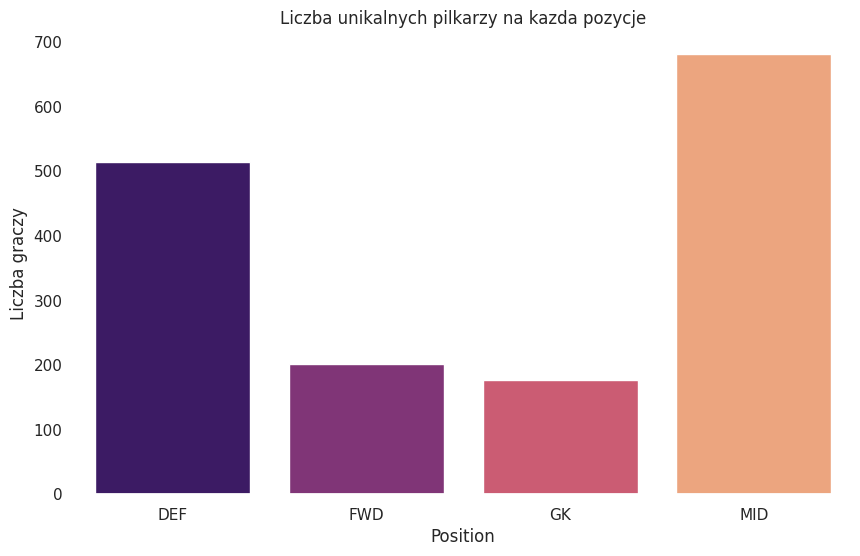

In [76]:
plt.figure(figsize=(10,6))
sns.barplot(data=data.groupby("position")["name"].nunique(), palette="magma", legend=False)
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [77]:
[c for c in data.columns if "points" in c]

['total_points']

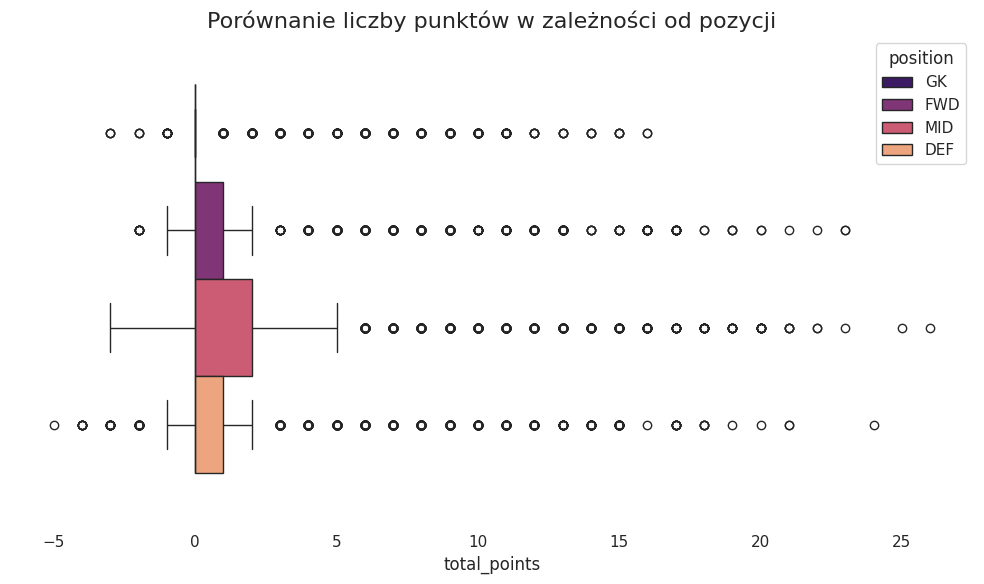

In [78]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position", palette="magma")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Skośność: 3.135
Kurtoza:    12.025
Udział zer:          61.8%


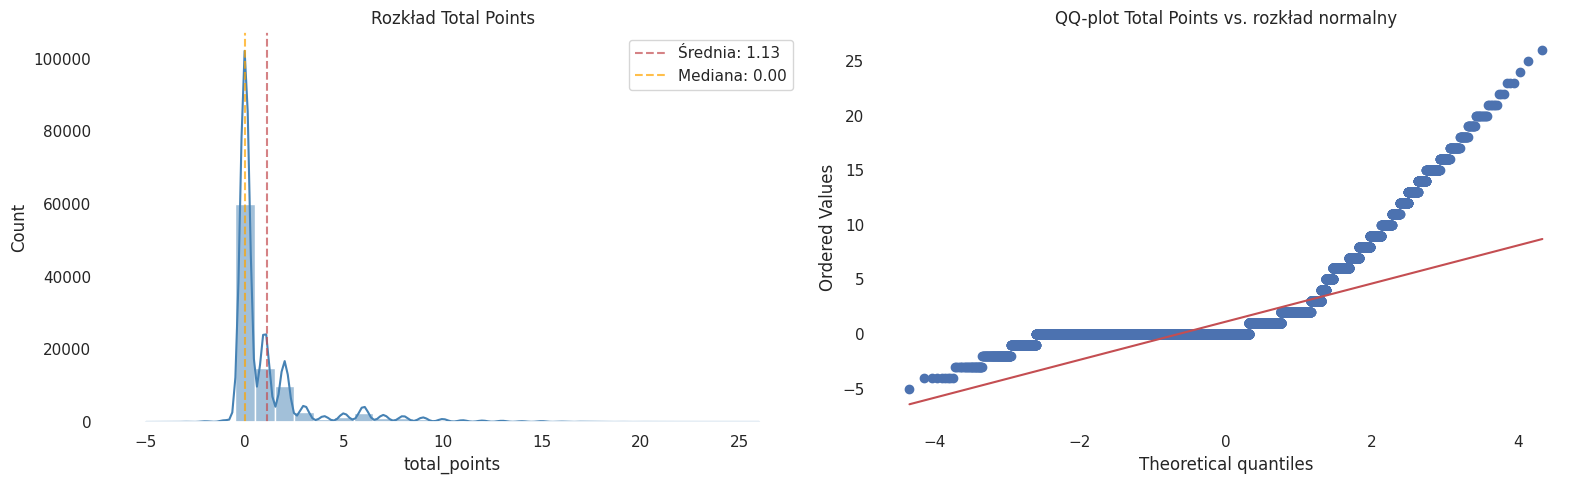

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.histplot(data.total_points, kde=True, discrete=True, bins=30,
             color='steelblue', ax=ax)
ax.axvline(data.total_points.mean(), linestyle='--', color='r', alpha=0.7,
           label=f"Średnia: {data.total_points.mean():.2f}")
ax.axvline(data.total_points.median(), linestyle='--', color='orange', alpha=0.7,
           label=f"Mediana: {data.total_points.median():.2f}")
ax.legend(loc='upper right')
ax.set_title('Rozkład Total Points')

ax2 = axes[1]
stats.probplot(data.total_points, dist='norm', plot=ax2)
ax2.set_title('QQ-plot Total Points vs. rozkład normalny')

plt.tight_layout()

skew = float(data.total_points.skew())
kurt = float(data.total_points.kurtosis())
zero_pct = (data.total_points == 0).mean() * 100
print(f"Skośność: {skew:.3f}")
print(f"Kurtoza:    {kurt:.3f}")
print(f"Udział zer:          {zero_pct:.1f}%")

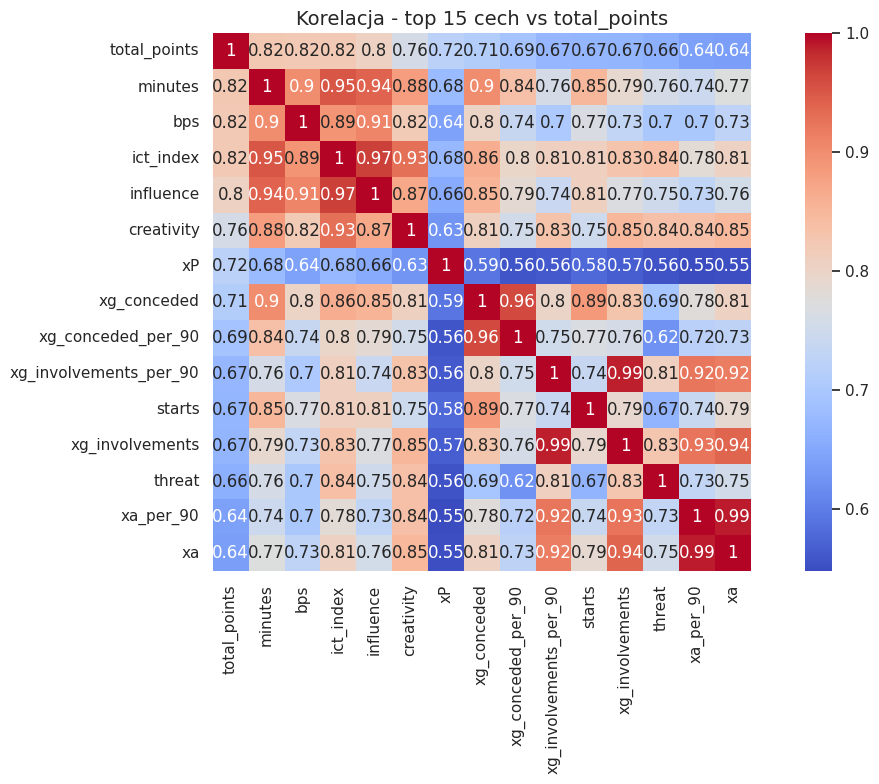

In [80]:
corr = data.select_dtypes(exclude=["object", "string"]).corr(method='spearman').apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)
plt.title("Korelacja - top 15 cech vs total_points", fontsize=14)
plt.tight_layout()

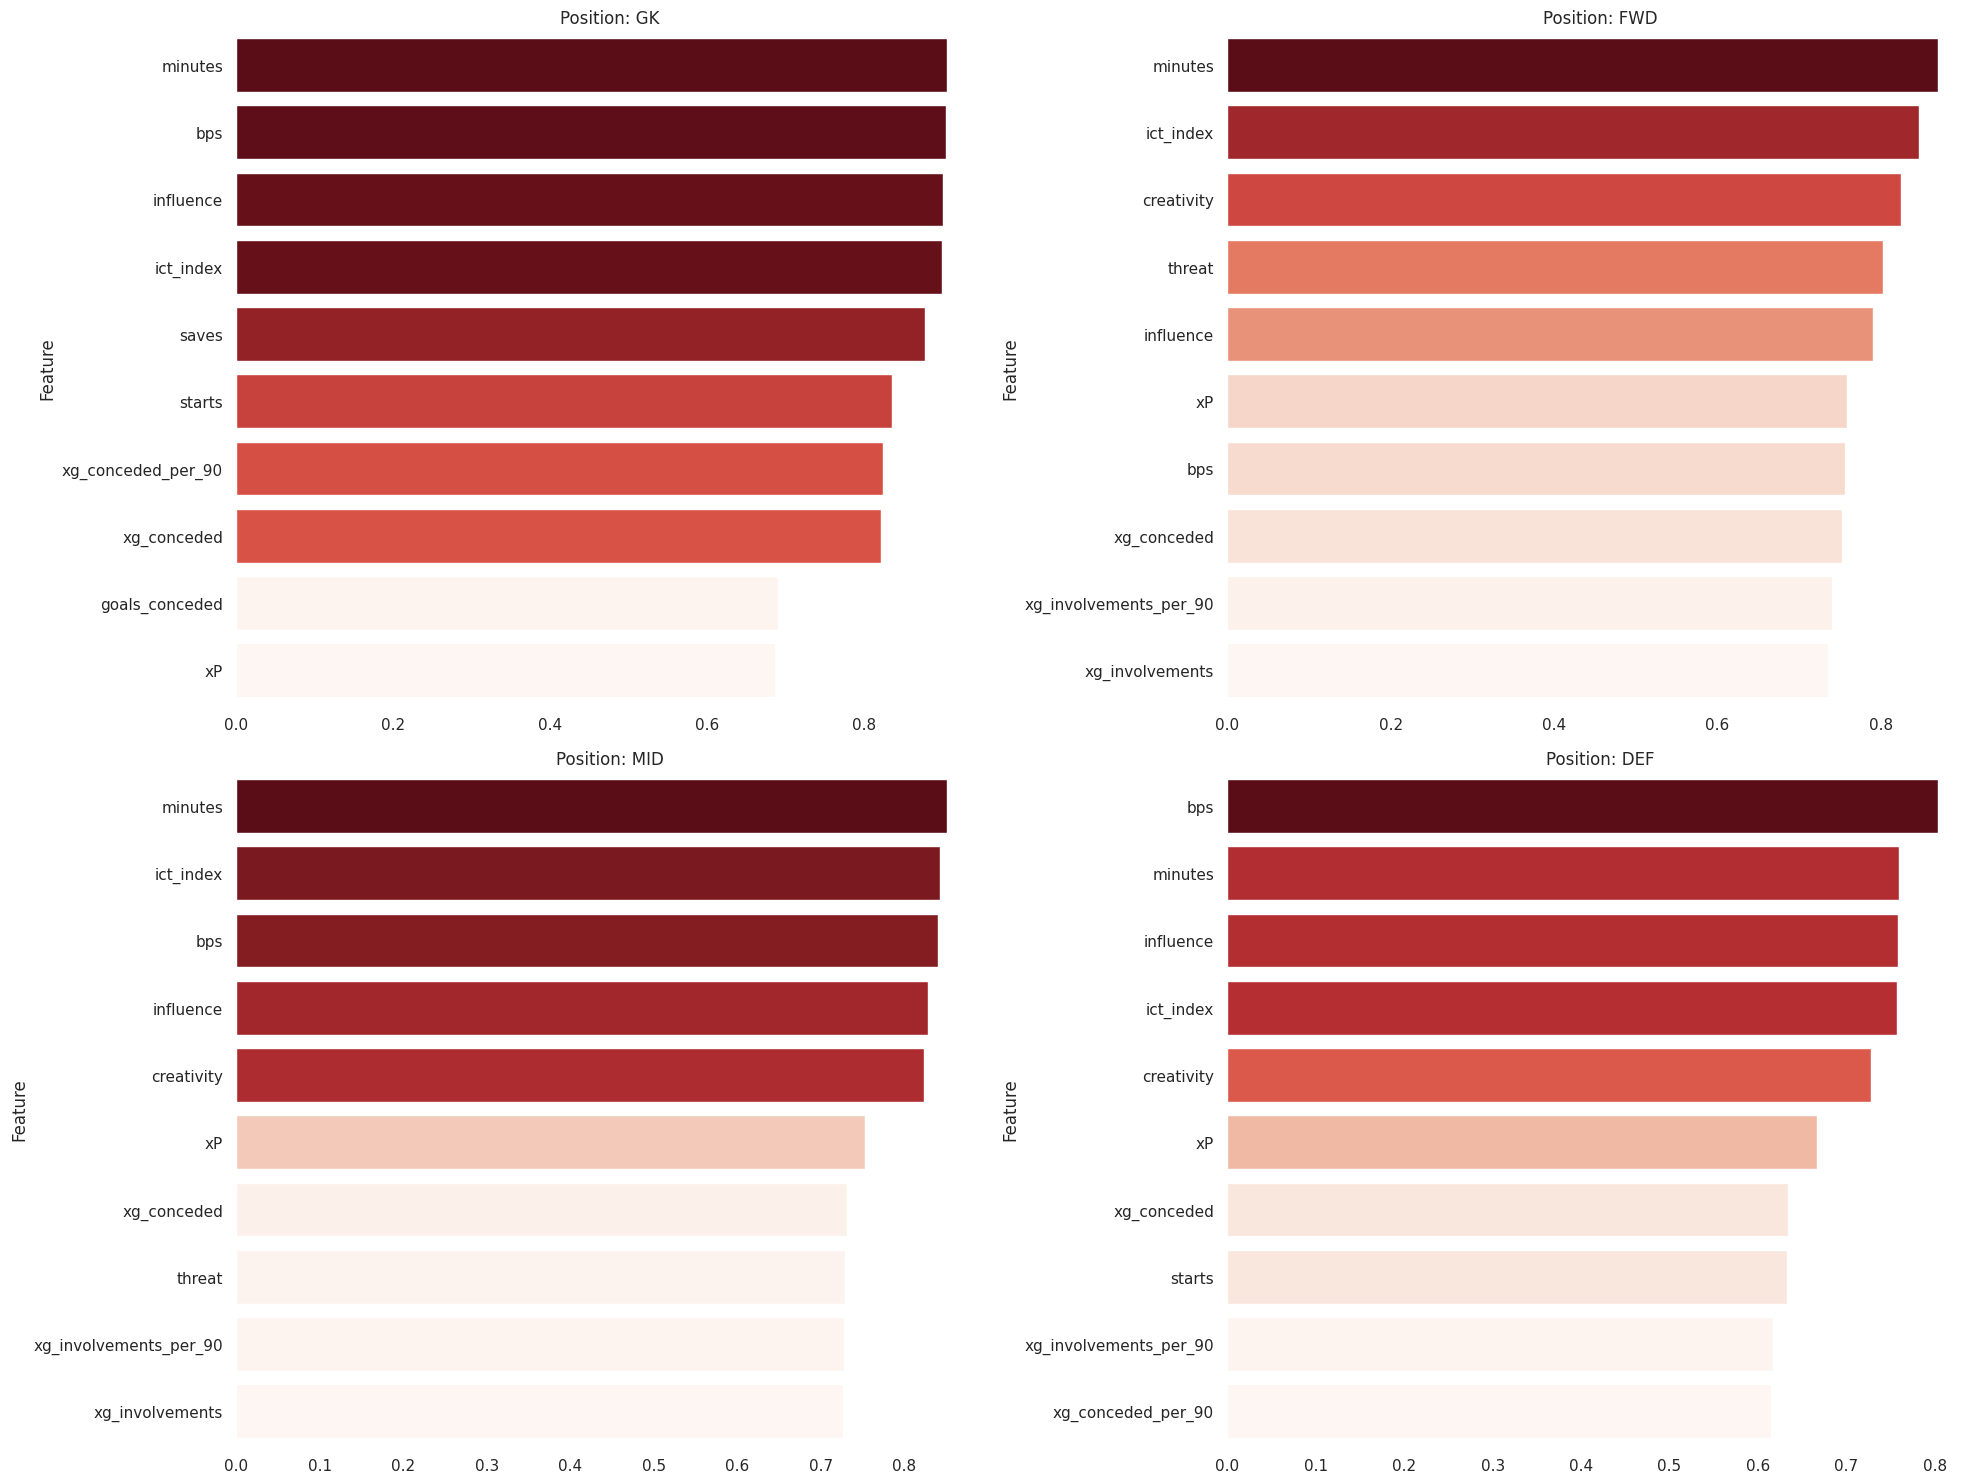

In [81]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) 
axes_flat = axes.flatten()

for idx, position in enumerate(data.position.unique()):
    subset = data[data.position == position].select_dtypes(exclude=["object", "string"])
    corr = subset.corr("spearman").apply(np.abs)
    
    plot_data = corr["total_points"].sort_values(ascending=False).head(11).drop(["total_points"])
    
    sns.barplot(
        x=plot_data.values,
        y=plot_data.index,
        ax=axes_flat[idx],
        hue=plot_data.values,
        palette="Reds",
        legend=False
    )
    
    axes_flat[idx].set_title(f"Position: {position}")
    axes_flat[idx].set_ylabel("Feature")

plt.tight_layout()

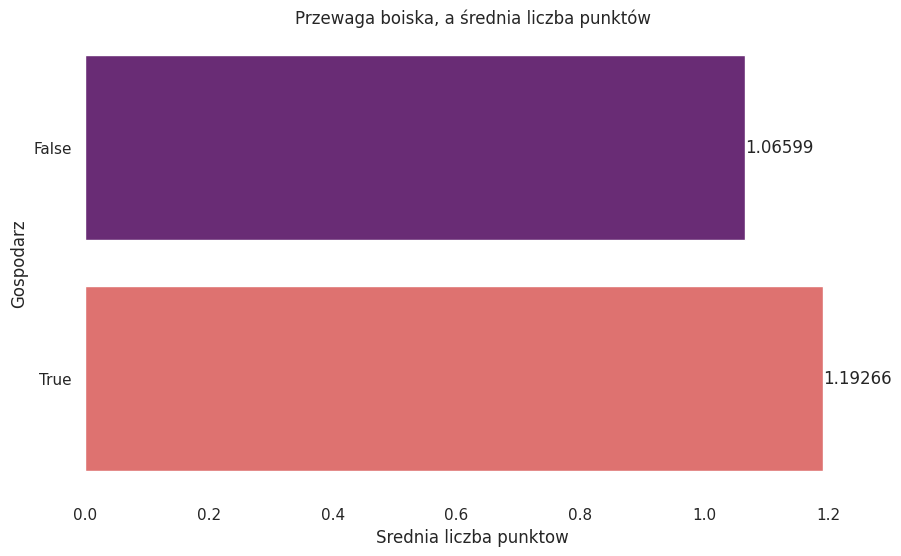

In [82]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    palette="magma",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [83]:
curr_gw = data[data.season==data.season.max()].gw.max()

In [84]:
"""fig = px.scatter(
    data[(data.season == data.season.max()) & (data.gw==curr_gw)],
    x="selected",
    y="total_points",
    color="position",
    facet_col="position",
    facet_col_wrap=2,
    hover_name="name", 
    hover_data={"selected": True, "total_points": True, "position": False},
    color_discrete_sequence=px.colors.sequential.Plasma,
    opacity=0.7,
    height=850,
    title="Punkty piłkarzy według pozycji i popularności"
)

fig.for_each_xaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d", 
    tickangle=0,
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    
))

fig.for_each_yaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d",
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    title_text="Suma punktów"
))

fig.update_layout(
    showlegend=False,
    template="plotly_dark",
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="#FFFFFF"
    ),    
    )


for annotation in fig["layout"]["annotations"]:
    annotation['font'] = dict(size=14, color="#FFFFFF", family="Arial Black")
    annotation['text'] = annotation['text'].split("=")[-1].upper()

fig.show(renderer="notebook")"""

'fig = px.scatter(\n    data[(data.season == data.season.max()) & (data.gw==curr_gw)],\n    x="selected",\n    y="total_points",\n    color="position",\n    facet_col="position",\n    facet_col_wrap=2,\n    hover_name="name", \n    hover_data={"selected": True, "total_points": True, "position": False},\n    color_discrete_sequence=px.colors.sequential.Plasma,\n    opacity=0.7,\n    height=850,\n    title="Punkty piłkarzy według pozycji i popularności"\n)\n\nfig.for_each_xaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d", \n    tickangle=0,\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n\n))\n\nfig.for_each_yaxis(lambda axis: axis.update(\n    showticklabels=True, \n    tickformat=",d",\n    showgrid=True,\n    gridcolor=\'rgba(255, 255, 255, 0.1)\',\n    title_text="Suma punktów"\n))\n\nfig.update_layout(\n    showlegend=False,\n    template="plotly_dark",\n    font=dict(\n        family="Arial, sans-serif",\n        size=12,\n        col

In [85]:
data[(data.season==data.season.max()) & (data.gw==curr_gw)].loc[
    (data.selected < data.selected.quantile(.5)) &
    (data.total_points > data.total_points.quantile(.9)) &
    (data.minutes > 0),
["name", "position", "selected", "total_points", "xP", "gw", "minutes"]].sort_values(by=["position", "total_points"], ascending=False)

,name,position,selected,total_points,xP,gw,minutes
5733,Pascal Groß,MID,1.0,16.0,14.1,33.0,1276.0
61366,Noah Okafor,MID,1.2,16.0,21.1,33.0,1489.0
35707,Ethan Ampadu,MID,0.4,12.0,10.5,33.0,2759.0
71062,Georginio Rutter,MID,0.3,12.0,8.1,33.0,1711.0
81773,Rayan Vitor Simplício Rocha,MID,1.4,11.0,8.6,33.0,792.0
...,...,...,...,...,...,...,...
64196,Ian Maatsen,DEF,0.6,5.0,3.0,33.0,1332.0
64197,Ian Maatsen,DEF,0.6,5.0,3.0,33.0,1332.0
71530,James Hill,DEF,6.4,5.0,5.4,33.0,1742.0
72020,Maxim De Cuyper,DEF,1.5,5.0,2.9,33.0,1173.0


In [86]:
team_x_stats = [c for c in data.columns if "x" in c and c!="ict_index" and ("team" in c or "opp" in c)]
player_x_stasts = [c for c in data.columns if "x" in c and c!="ict_index" and c not in team_x_stats and c !="xP"]

player_x_stasts

['xa',
 'xg_involvements',
 'xg',
 'xg_conceded',
 'xa_per_90',
 'xg_involvements_per_90',
 'xg_per_90',
 'xg_conceded_per_90']

In [87]:
data.position.unique()

<ArrowStringArray>
['GK', 'FWD', 'MID', 'DEF']
Length: 4, dtype: str

In [88]:
"""radar_plot_x_stats(df=data,
                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],\n                   stats=player_x_stasts)'

In [89]:
"""radar_plot_x_stats(df=data,
                   players=['Kenny Tete', "Marc Guéhi", "Lewis Hall",  'Trevoh Chalobah'],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=[\'Kenny Tete\', "Marc Guéhi", "Lewis Hall",  \'Trevoh Chalobah\'],\n                   stats=player_x_stasts)'

In [90]:
pca_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("pca", PCA())
])

umap_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("umap", umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.001, random_state=77))
])

In [91]:
X = data.select_dtypes(exclude="object").drop(columns=["gw", "round", "code", "element", "season"])

In [92]:
pca1 = pca_pipe.fit_transform(X)


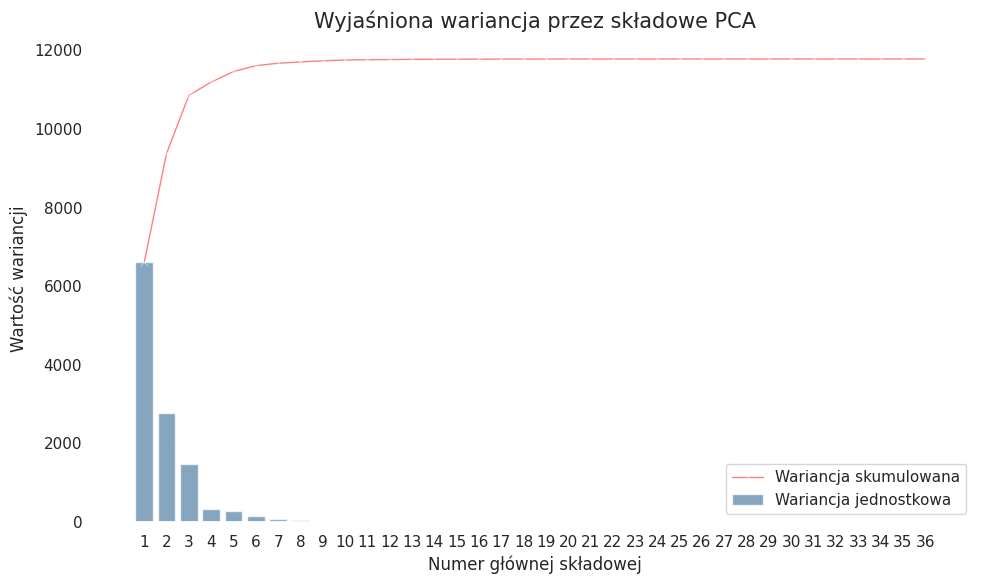

In [93]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1)), y=pca_pipe.named_steps["pca"].explained_variance_, color="steelblue", alpha=0.7, label="Wariancja jednostkowa")

sns.lineplot(x=range(len(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1))), y=np.cumsum(pca_pipe.named_steps["pca"].explained_variance_), color="red", marker="x", linewidth=1, alpha=.5, label="Wariancja skumulowana")

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title("Wyjaśniona wariancja przez składowe PCA", fontsize=15)
plt.xlabel("Numer głównej składowej", fontsize=12)
plt.ylabel("Wartość wariancji", fontsize=12)
plt.legend()

plt.grid(axis="y", alpha=.5)
plt.tight_layout()

In [94]:
pca_pipe = Pipeline([
    ("scale", RobustScaler()),
    ("pca", PCA(2))
])

pca2 = pca_pipe.fit_transform(X)


Text(0.5, 1.0, 'Wpływ cech na główne składowe (Loadings)')

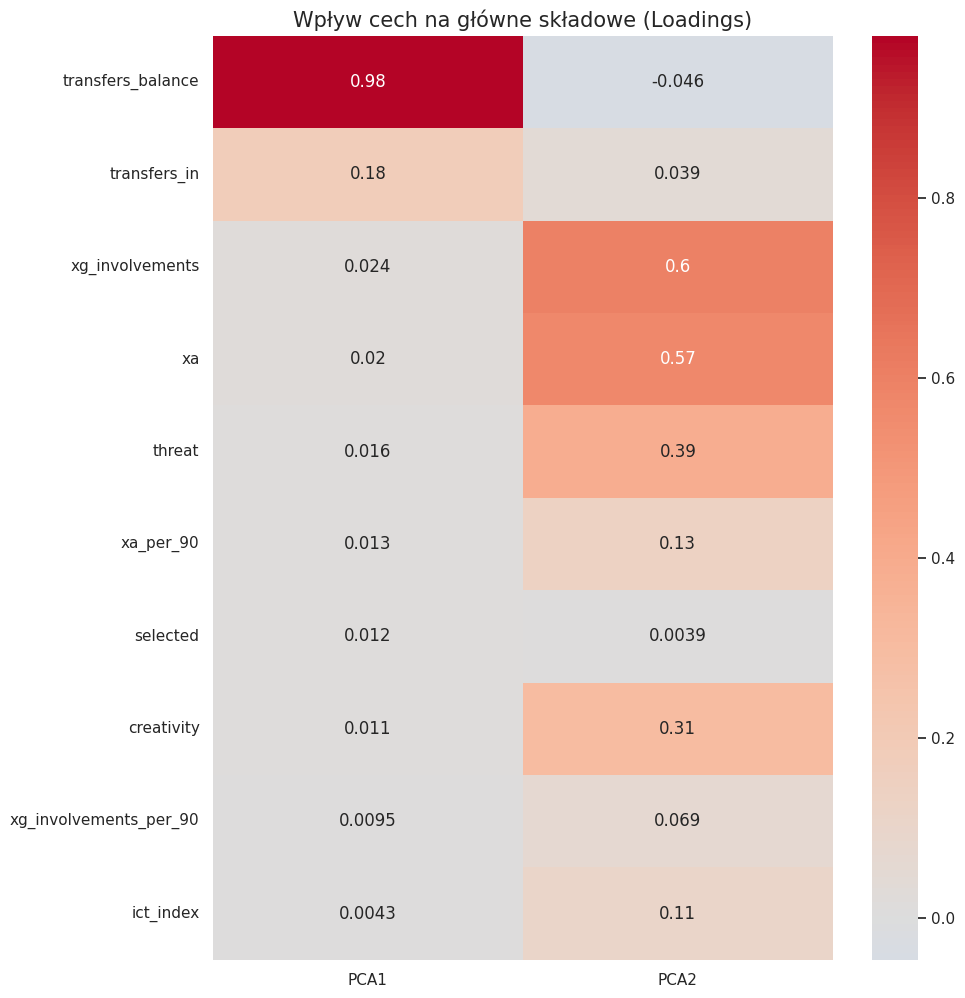

In [95]:
loadings = pd.DataFrame(
    pca_pipe.named_steps["pca"].components_[:2].T, 
    columns=['PCA1', 'PCA2'], 
    index=X.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings.sort_values(by=["PCA1", "PCA2"], ascending=False).head(10), 
            annot=True, cmap='coolwarm', center=0)

plt.title("Wpływ cech na główne składowe (Loadings)", fontsize=15)

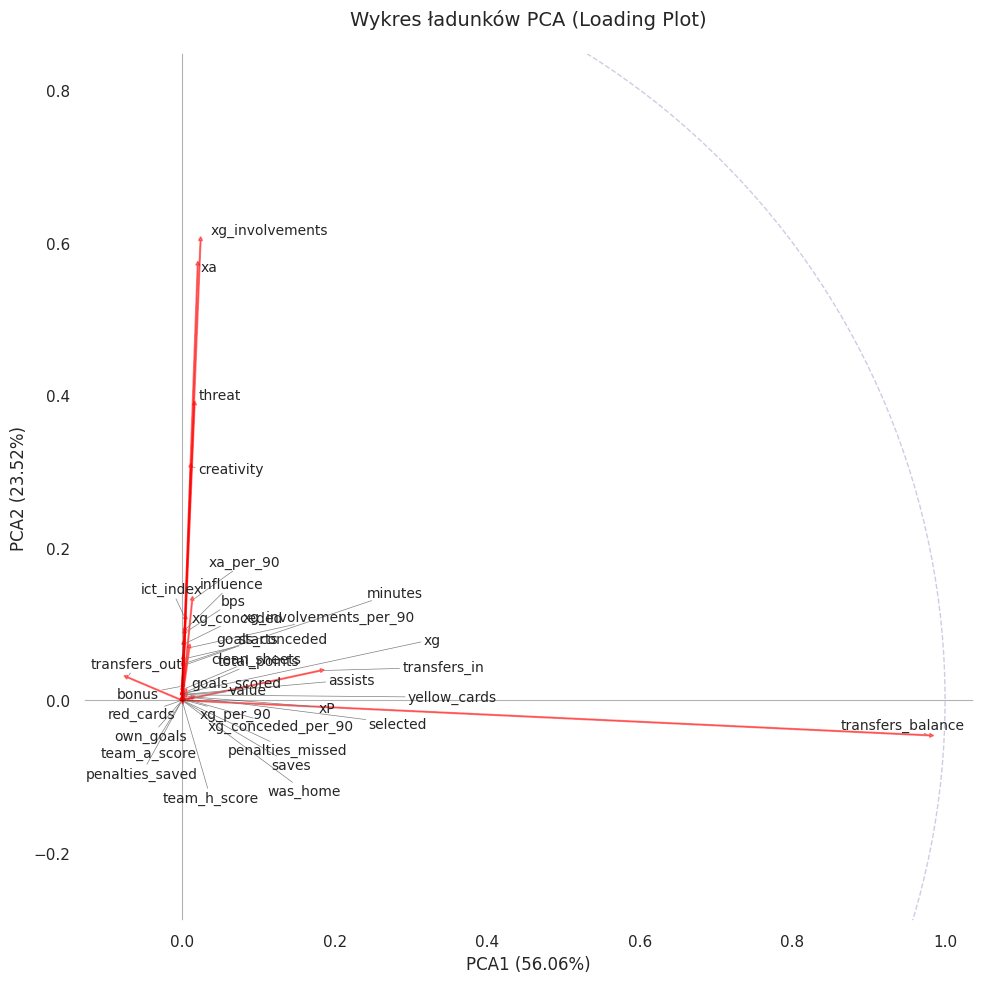

In [96]:
def plot_pca_loadings(loadings, pca_obj):
    plt.figure(figsize=(10, 10))
    
    texts = []
    for i, feature in enumerate(loadings.index):
        x = loadings.iloc[i, 0]
        y = loadings.iloc[i, 1]
        
        plt.arrow(0, 0, x, y, color='red', alpha=0.5, head_width=0.005, head_length=0.005)
        
        texts.append(plt.text(x, y, feature, fontsize=10, fontweight='medium'))

    circle = plt.Circle((0,0), 1, color='navy', fill=False, linestyle='--', alpha=0.2)
    plt.gca().add_artist(circle)

    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.axis('equal')
    
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    
    plt.xlabel(f'PCA1 ({pca_obj.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA2 ({pca_obj.explained_variance_ratio_[1]:.2%})')
    
    plt.title('Wykres ładunków PCA (Loading Plot)', fontsize=14, pad=20)
    plt.grid(alpha=0.2)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()

plot_pca_loadings(loadings, pca_pipe.named_steps["pca"])

In [97]:
embedding = umap_pipe.fit_transform(X)

In [98]:
df_umap = pd.concat([data, pd.DataFrame(embedding, columns=["umap_x", "umap_y"])], axis=1)

<Axes: xlabel='umap_x', ylabel='umap_y'>

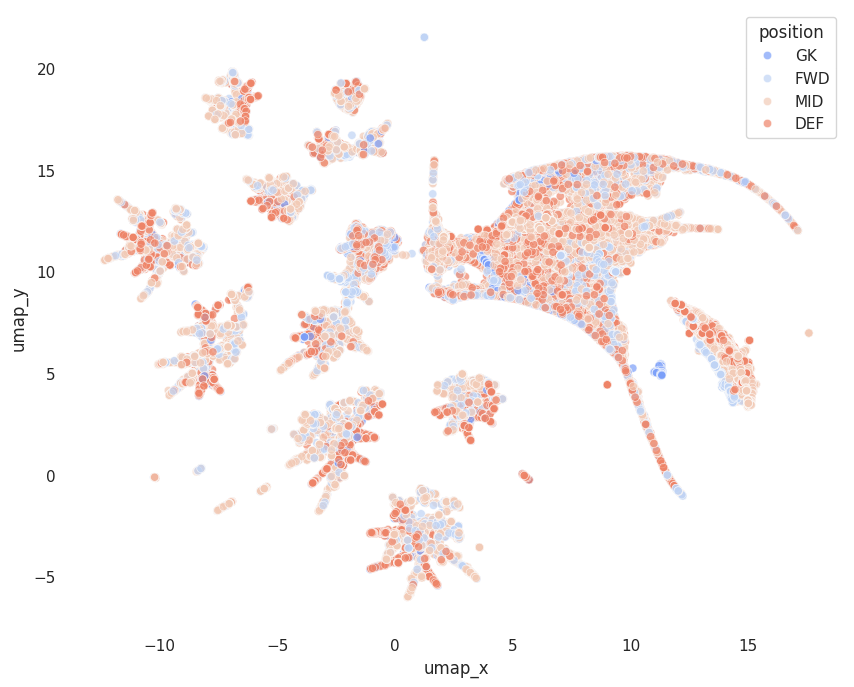

In [99]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_umap, 
    x='umap_x', 
    y='umap_y', 
    hue='position',
    palette='coolwarm',
    alpha=0.7
)

In [100]:
"""positions = data.position.unique()
K_RANGE = range(2, 9)

fig, axes = plt.subplots(len(positions), 2, figsize=(14, 4 * len(positions)))

optimal_k = {} 

num_cols = (data.select_dtypes('number')
            .columns
            .drop(['gw', 'round', 'code', 'element', 'season', 'id',
                   'total_points'], errors='ignore'))

for row_idx, pos in enumerate(positions):
    d = data[data.position == pos][num_cols].fillna(0)
    X_pos = RobustScaler().fit_transform(d)

    inertias, silhouettes = [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X_pos)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_pos, labels))

    ax_e = axes[row_idx, 0]
    ax_e.plot(list(K_RANGE), inertias, marker='o', color='steelblue')
    ax_e.set_title(f"{pos} – Elbow (inercja)")
    ax_e.set_xlabel('k')
    ax_e.set_ylabel('Inercja')
    ax_e.grid(alpha=0.3)

    ax_s = axes[row_idx, 1]
    ax_s.plot(list(K_RANGE), silhouettes, marker='s', color='tomato')
    ax_s.set_title(f"{pos} – Silhouette score")
    ax_s.set_xlabel('k')
    ax_s.set_ylabel('Silhouette')
    ax_s.grid(alpha=0.3)

    best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
    optimal_k[pos] = best_k
    ax_s.axvline(best_k, color='orange', linestyle='--',
                 label=f'Optimum k={best_k}')
    ax_s.legend(fontsize=9)

plt.suptitle('Wybór liczby klastrów per pozycja', fontsize=14, y=1.01)
plt.tight_layout()
"""

'positions = data.position.unique()\nK_RANGE = range(2, 9)\n\nfig, axes = plt.subplots(len(positions), 2, figsize=(14, 4 * len(positions)))\n\noptimal_k = {} \n\nnum_cols = (data.select_dtypes(\'number\')\n            .columns\n            .drop([\'gw\', \'round\', \'code\', \'element\', \'season\', \'id\',\n                   \'total_points\'], errors=\'ignore\'))\n\nfor row_idx, pos in enumerate(positions):\n    d = data[data.position == pos][num_cols].fillna(0)\n    X_pos = RobustScaler().fit_transform(d)\n\n    inertias, silhouettes = [], []\n    for k in K_RANGE:\n        km = KMeans(n_clusters=k, n_init=10, random_state=42)\n        labels = km.fit_predict(X_pos)\n        inertias.append(km.inertia_)\n        silhouettes.append(silhouette_score(X_pos, labels))\n\n    ax_e = axes[row_idx, 0]\n    ax_e.plot(list(K_RANGE), inertias, marker=\'o\', color=\'steelblue\')\n    ax_e.set_title(f"{pos} – Elbow (inercja)")\n    ax_e.set_xlabel(\'k\')\n    ax_e.set_ylabel(\'Inercja\')\n    ax

In [101]:
def cluster_and_test(data, k_map, season, test_features=None, num_drop=None):

    if test_features is None:
        test_features = ['total_points', 'minutes', 'xg_per_90', 'xa_per_90',
                         'xg_conceded_per_90', 'team_xp', 'opp_xp']
    if num_drop is None:
        num_drop = ['gw', 'round', 'code', 'element', 'season', 'id',
                    'total_points', 'minutes']

    df = data[data.season == season].copy()
    if df.empty:
        raise ValueError(f"Brak danych dla sezonu: {season}. "
                         f"Dostępne sezony: {data.season.unique()}")

    num_cols = df.select_dtypes('number').columns.drop(num_drop, errors='ignore')

    positions = [p for p in df.position.unique() if p in k_map]
    n_pos = len(positions)
    fig, axes = plt.subplots(
        (n_pos + 1) // 2, 2, figsize=(15, 6 * ((n_pos + 1) // 2))
    )
    axes = np.array(axes).flatten()
    cluster_results = {}

    for ax, pos in zip(axes, positions):
        d = df[df.position == pos].copy().reset_index(drop=True)
        X = RobustScaler().fit_transform(d[num_cols].fillna(0))
        k = k_map.get(pos, 3)

        d['cluster'] = KMeans(k, n_init=10, random_state=42).fit_predict(X)
        pca_coords = PCA(2).fit_transform(X)
        d['pca_x'], d['pca_y'] = pca_coords[:, 0], pca_coords[:, 1]

        d_plot = d.groupby(['name', 'cluster'], as_index=False)[['pca_x', 'pca_y']].mean()

        sns.scatterplot(data=d_plot, x='pca_x', y='pca_y', hue='cluster',
                        ax=ax, palette='viridis', s=50)
        txts = [ax.text(r.pca_x, r.pca_y, r['name'], fontsize=7)
                for c in range(k)
                for _, r in d_plot[d_plot.cluster == c].head(5).iterrows()]
        adjust_text(txts, ax=ax, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
        ax.set_title(f"{pos}  (k={k})")
        cluster_results[pos] = d

    for ax in axes[len(positions):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Kruskal-Wallis + Bonferroni ───────────────────────────────────────────
    rows = []
    for pos, d in cluster_results.items():
        feats = [f for f in test_features if f in d.columns]
        if not feats:
            continue

        pvals, hstats = [], []
        for feat in feats:
            groups = [d[d.cluster == c][feat].dropna().values for c in d.cluster.unique()]
            try:
                h, p = kruskal(*groups)
            except Exception:
                h, p = np.nan, 1.0
            hstats.append(h)
            pvals.append(p)

        reject, p_corr, _, _ = multipletests(pvals, method='bonferroni')
        n, k_pos = len(d), d.cluster.nunique()
        eta2 = [(h - k_pos + 1) / (n - k_pos) if not np.isnan(h) else np.nan
                for h in hstats]

        for feat, h, p, pc, sig, e2 in zip(feats, hstats, pvals, p_corr, reject, eta2):
            rows.append(dict(position=pos, feature=feat,
                             H_stat=round(h, 3) if not np.isnan(h) else np.nan,
                             p_bonferroni=round(pc, 4), significant=sig,
                             eta_squared=round(e2, 4) if not np.isnan(e2) else np.nan))

    if not rows:
        raise RuntimeError("Brak wyników Kruskala – sprawdź test_features i dane.")

    # ── Heatmapa ──────────────────────────────────────────────────────────────
    summary = pd.DataFrame(rows)
    pivot_eta = summary.pivot_table(index='feature', columns='position',
                                    values='eta_squared', aggfunc='first')
    pivot_sig = summary.pivot_table(index='feature', columns='position',
                                    values='significant', aggfunc='first')

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(pivot_eta, annot=True, fmt='.3f', cmap='YlOrRd',
                     linewidths=0.5, cbar_kws={'label': 'Eta²'})
    for i, feat in enumerate(pivot_eta.index):
        for j, pos in enumerate(pivot_eta.columns):
            val = pivot_sig.loc[feat, pos]
            if pd.notna(val) and val:
                ax.text(j + 0.85, i + 0.25, '*', fontsize=14,
                        color='navy', fontweight='bold')

    plt.title(f'Eta² per pozycja | sezon: {season} | * = istotne po Bonferronim')
    plt.tight_layout()
    plt.show()
    print("Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt")

    return summary, cluster_results

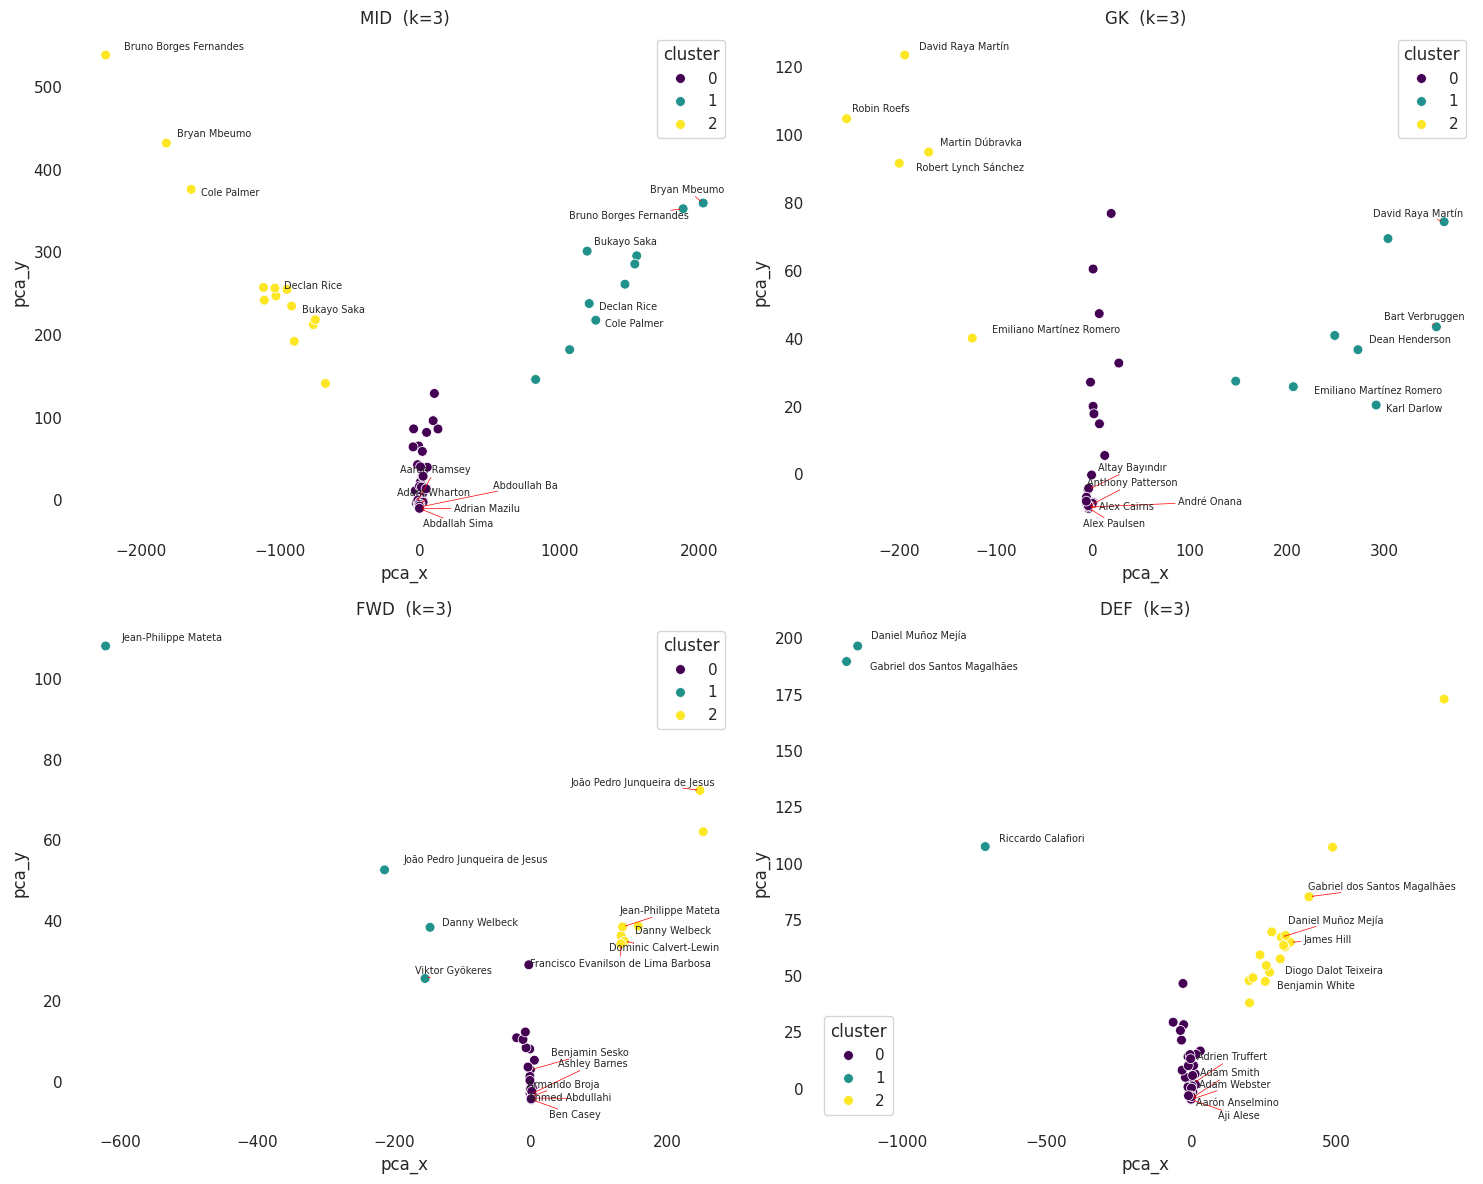

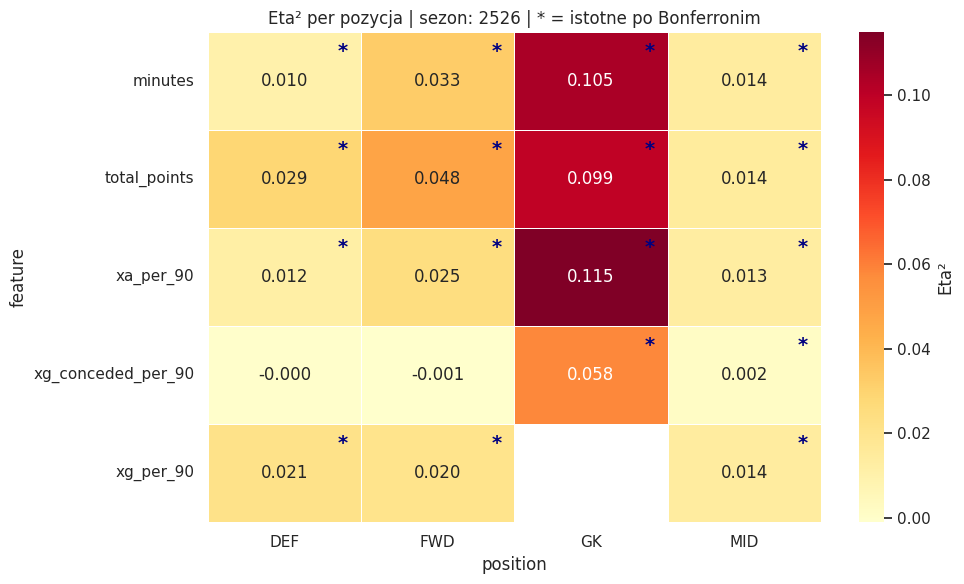

Eta² ≈ 0.01 mały | 0.06 średni | 0.14+ duży efekt


In [102]:
summary, clusters = cluster_and_test(data=data, k_map={'FWD': 3, 'MID': 3, 'DEF': 3, 'GK': 3}, season=2526)

In [103]:
data.to_parquet(config.TIDY_DATA_PATH)